In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/porro1925/porro_1925_mapped_soiusa.csv')

sector_counts = df['Mountain Sector'].value_counts().sort_values(ascending=True)
group_counts = df['Mountain Group'].value_counts().sort_values(ascending=True)
sector_counts

Mountain Sector
APENNINES                     1
JULIAN ALPS                   4
COTTIAN ALPS                 10
MARITIME ALPS                11
BERGAMO ALPS AND PREALPS     16
DOLOMITES                    41
LEPONTINE ALPS               44
PENNINE ALPS                 99
WESTERN RHAETIAN ALPS       105
GRAIAN ALPS                 105
EASTERN RHAETIAN ALPS       123
SOUTHERN RHAETIAN ALPS      200
Name: count, dtype: int64

In [152]:
sectors_by_count = df['Mountain Sector'].value_counts().index.tolist()
num_sectors = len(sectors_by_count)

palette_colors = plt.cm.turbo(np.linspace(0, 1, num_sectors))

sector_to_color = {sector: color for sector, color in zip(sectors_by_count, palette_colors)}

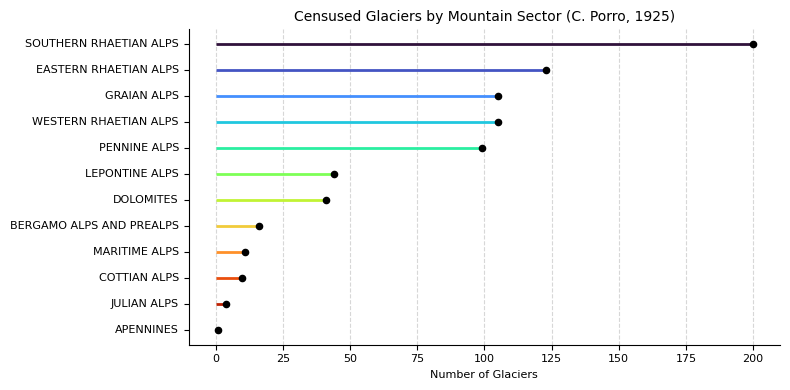

In [153]:
import textwrap

colors_for_plot1 = [sector_to_color[sector] for sector in sector_counts.index]

plt.figure(figsize=(8, 4), dpi=100) 

plt.hlines(y=range(len(sector_counts)), xmin=0, xmax=sector_counts.values, color=colors_for_plot1, linewidth=2)
plt.scatter(x=sector_counts.values, y=range(len(sector_counts)), color='black', s=20, zorder=3)

wrapped_sector_labels = [textwrap.fill(label, width=40) for label in sector_counts.index]
plt.yticks(range(len(sector_counts)), wrapped_sector_labels, fontsize=8, ha='right', va='center')
plt.xticks(fontsize=8)

plt.title("Censused Glaciers by Mountain Sector (C. Porro, 1925)", fontsize=10)
plt.xlabel("Number of Glaciers", fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

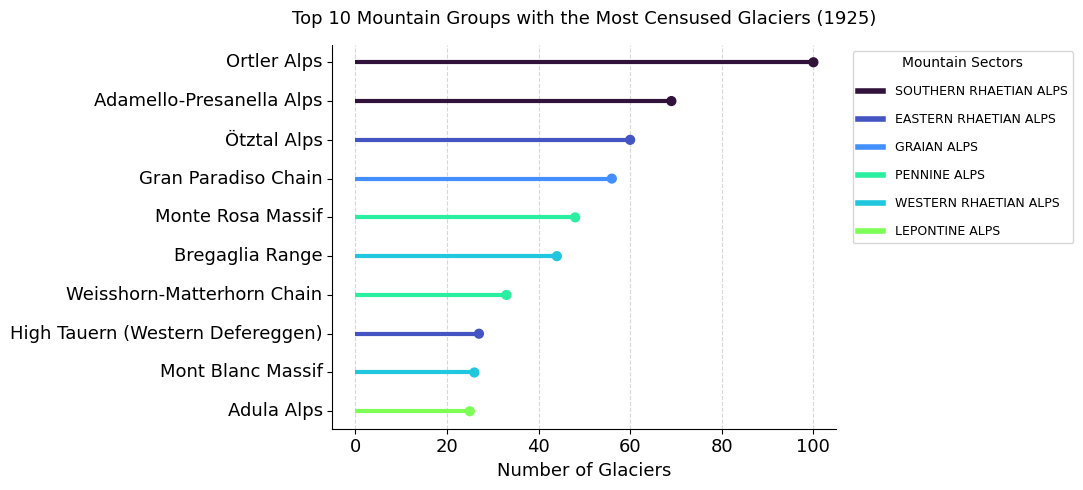

In [ ]:
from matplotlib.lines import Line2D

top_groups = group_counts.tail(10)

group_to_sector = df.groupby('Mountain Group')['Mountain Sector'].first()

# Pesca il colore corretto dal dizionario mappato per importanza del settore
colors_for_plot2 = [sector_to_color[group_to_sector[group]] for group in top_groups.index]
wrapped_group_labels = [textwrap.fill(label, width=50) for label in top_groups.index]

plt.figure(figsize=(11, 5), dpi=100) 

plt.hlines(y=range(len(top_groups)), xmin=0, xmax=top_groups.values, color=colors_for_plot2, linewidth=3)
plt.scatter(x=top_groups.values, y=range(len(top_groups)), color=colors_for_plot2, s=40, zorder=3)

plt.yticks(range(len(top_groups)), wrapped_group_labels, fontsize=13, ha='right', va='center')
plt.xticks(fontsize=13)

plt.title("Top 10 Mountain Groups with the Most Censused Glaciers (1925)", fontsize=13, pad=15)
plt.xlabel("Number of Glaciers", fontsize=13)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Legenda univoca
legend_elements = []
sectors_seen = set()

for group_name in reversed(top_groups.index):
    sector_name = group_to_sector[group_name]
    
    if sector_name not in sectors_seen:
        sectors_seen.add(sector_name)
        color = sector_to_color[sector_name]
        
        wrapped_sector_name = textwrap.fill(sector_name, width=35)
        legend_elements.append(
            Line2D([0], [0], color=color, lw=4, label=wrapped_sector_name)
        )

plt.legend(
    handles=legend_elements, 
    title="Mountain Sectors", 
    fontsize=9, 
    title_fontsize=10, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    handletextpad=1.0,
    labelspacing=1.2
)

plt.tight_layout()
plt.show()